# Fake News Detection — Notebook 2: Feature Engineering


**Input:** `data/lemmatized.csv`  
**Outputs:** `data/tfidf_dataset.csv`, `data/word2vec_dataset.csv`, `data/sentence2vec_dataset.csv`, `data/doc2vec_dataset.csv`

---

## 0. Setup

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

from vectorizers import build_tfidf, build_word2vec, build_sentence2vec, build_doc2vec

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})
print('Imports OK')


Imports OK


## 1. Load Preprocessed Data

In [2]:
df = pd.read_csv('../data/lemmatized.csv')
df['text']  = df['text'].fillna('')
df['title'] = df['title'].fillna('')

print(f'Shape: {df.shape}')
print(f'Label distribution:\n{df["label"].value_counts()}')
df.head(3)


Shape: (72134, 3)
Label distribution:
label
1    37106
0    35028
Name: count, dtype: int64


,title,text,label
0,LAW ENFORCEMENT HIGH ALERT Following Threats C...,comment expected Barack Obama Members FYF911 F...,1
1,,post vote Hillary already,1
2,UNBELIEVABLE OBAMAS ATTORNEY GENERAL SAYS CHAR...,demonstrator gathered last night exercising co...,1


## 2. TF-IDF Vectorisation

Fit a unigram+bigram TF-IDF matrix (2,000 features) on the article body.

In [3]:
tfidf_df, tfidf_vectorizer = build_tfidf(
    df, text_col='text', max_features=2000, ngram_range=(1, 2)
)

print(f'TF-IDF feature matrix: {tfidf_df.shape}')
tfidf_df.head(3)


TF-IDF feature matrix: (72134, 2000)


,000,10,100,11,12,13,14,15,16,17,...,yes,yesterday,york,york city,york times,young,youre,youtube,zero,zone
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.036255,0.0,0.049488,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0


In [4]:
# Save TF-IDF dataset (feature columns only — label added below)
tfidf_df.to_csv('../data/tfidf_dataset.csv', index=False)
print('Saved data/tfidf_dataset.csv')


Saved data/tfidf_dataset.csv


### 2.1 Top TF-IDF Features

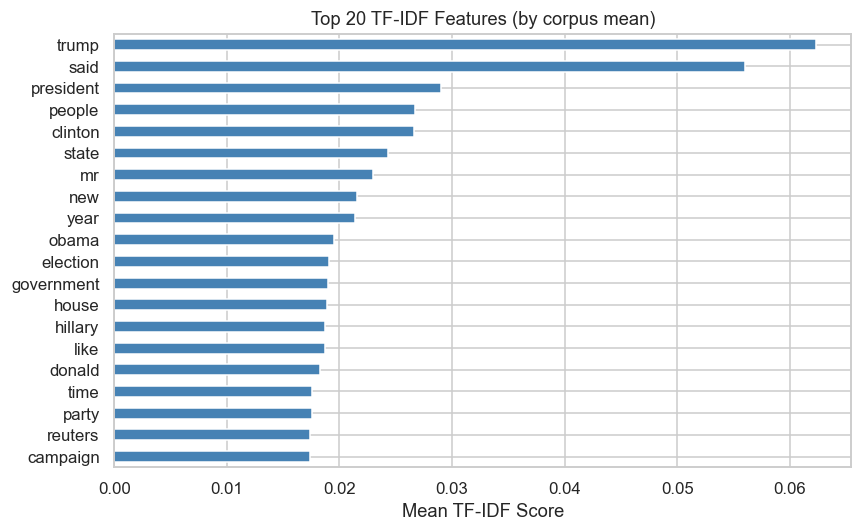

In [5]:
top_features = tfidf_df.mean().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 5))
top_features.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set(xlabel='Mean TF-IDF Score', title='Top 20 TF-IDF Features (by corpus mean)')
plt.tight_layout(); plt.show()


## 3. Word2Vec (Mean-Pooled)

Train a skip-gram Word2Vec model (100-dim) and average token vectors per document.

In [6]:
w2v_df, w2v_model = build_word2vec(
    df,
    text_col='text',
    vector_size=100,
    window=5,
    min_count=2,
    epochs=10,
    save_path='../data/word2vec.model',
)

print(f'Word2Vec feature matrix: {w2v_df.shape}')
w2v_df.head(3)


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Word2Vec feature matrix: (72134, 100)


,w2v_0,w2v_1,w2v_2,w2v_3,w2v_4,w2v_5,w2v_6,w2v_7,w2v_8,w2v_9,...,w2v_90,w2v_91,w2v_92,w2v_93,w2v_94,w2v_95,w2v_96,w2v_97,w2v_98,w2v_99
0,-0.170660,0.069268,0.131011,0.086645,-0.057890,-0.373490,0.086643,0.323063,-0.166956,-0.141527,...,0.132737,-0.036615,-0.144278,0.100282,0.279883,-0.003033,0.166805,-0.249410,-0.033718,-0.064076
1,-0.061316,0.204030,0.223338,-0.068793,0.015239,-0.402977,0.214279,0.273062,-0.268610,-0.157942,...,0.158763,0.182191,-0.113759,0.026896,0.249278,-0.102216,-0.013025,-0.220201,0.094534,-0.180503
2,-0.196342,0.012331,0.027967,0.026926,-0.162210,-0.453141,0.067423,0.413580,-0.165345,-0.153347,...,0.250472,0.126908,-0.227304,0.067903,0.125177,-0.009377,0.021828,-0.482456,0.174566,-0.221637


In [7]:
df_w2v = pd.concat([df[['title', 'text', 'label']].reset_index(drop=True),
                    w2v_df.reset_index(drop=True)], axis=1)
df_w2v.to_csv('../data/word2vec_dataset.csv', index=False)
print('Saved data/word2vec_dataset.csv')


Saved data/word2vec_dataset.csv


## 4. Sentence2Vec (TF-IDF-Weighted Word2Vec)

Weight each token's Word2Vec vector by its TF-IDF score, then average. This gives more important words higher influence on the document representation.

In [8]:
s2v_df = build_sentence2vec(df, w2v_model, tfidf_df, text_col='text')

print(f'Sentence2Vec feature matrix: {s2v_df.shape}')
s2v_df.head(3)


Sentence2Vec feature matrix: (72134, 100)


,s2v_0,s2v_1,s2v_2,s2v_3,s2v_4,s2v_5,s2v_6,s2v_7,s2v_8,s2v_9,...,s2v_90,s2v_91,s2v_92,s2v_93,s2v_94,s2v_95,s2v_96,s2v_97,s2v_98,s2v_99
0,-0.029827,-0.008690,0.031666,0.006148,-0.033500,-0.077917,0.019927,0.058228,-0.017964,-0.015612,...,0.013750,-0.021472,-0.026439,0.036319,0.046112,-0.010760,0.052963,-0.030995,-0.002311,-0.032149
1,-0.025380,0.124319,0.160154,-0.060220,-0.032074,-0.204752,0.126985,0.137368,-0.092235,-0.057900,...,0.049603,0.129047,-0.046393,0.031039,0.170482,-0.078745,-0.024230,-0.061098,0.070828,-0.082906
2,-0.053980,0.001098,-0.001788,0.032529,-0.043377,-0.157648,0.020771,0.145673,-0.063126,-0.023198,...,0.070970,0.051752,-0.112354,0.053441,0.076543,-0.001205,-0.013488,-0.131949,0.052413,-0.098231


In [9]:
df_s2v = pd.concat([df[['title', 'text', 'label']].reset_index(drop=True),
                    s2v_df.reset_index(drop=True)], axis=1)
df_s2v.to_csv('../data/sentence2vec_dataset.csv', index=False)
print('Saved data/sentence2vec_dataset.csv')


Saved data/sentence2vec_dataset.csv


## 5. Doc2Vec

Train a Doc2Vec (PV-DM) model on combined title+text. Unlike Word2Vec, Doc2Vec learns a dedicated embedding for each document.

In [10]:
d2v_df, d2v_model = build_doc2vec(
    df,
    text_col='text',
    title_col='title',
    vector_size=100,
    window=5,
    min_count=2,
    epochs=40,
    save_path='../data/doc2vec.model',
)

print(f'Doc2Vec feature matrix: {d2v_df.shape}')
d2v_df.head(3)


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Doc2Vec feature matrix: (72134, 100)


,d2v_0,d2v_1,d2v_2,d2v_3,d2v_4,d2v_5,d2v_6,d2v_7,d2v_8,d2v_9,...,d2v_90,d2v_91,d2v_92,d2v_93,d2v_94,d2v_95,d2v_96,d2v_97,d2v_98,d2v_99
0,-1.397744,-0.670007,-3.258345,1.700723,0.415204,-1.385069,-0.017436,0.828107,-1.509341,-3.455087,...,0.384438,1.857981,-1.785878,0.192473,-0.992329,-0.752172,2.858266,-1.057044,0.500900,-0.997436
1,0.088113,-0.065288,0.039149,0.195952,0.122588,-0.281317,0.414113,0.081589,-0.395115,-0.300695,...,0.041312,-0.207005,-0.099590,-0.155238,0.233621,0.395081,0.294228,-0.136248,0.047278,0.273236
2,-0.163417,0.490667,-0.536204,0.572264,0.112882,-0.532850,0.056821,0.822754,-0.749739,-0.455825,...,0.332894,0.211749,-0.282382,-0.471213,-0.192272,0.200810,0.486781,0.060008,-0.345940,-0.218029


In [11]:
df_d2v = pd.concat([df[['title', 'text', 'label']].reset_index(drop=True),
                    d2v_df.reset_index(drop=True)], axis=1)
df_d2v.to_csv('../data/doc2vec_dataset.csv', index=False)
print('Saved data/doc2vec_dataset.csv')


Saved data/doc2vec_dataset.csv


## 6. Baseline Evaluation — Logistic Regression

Quick benchmark: how well does each representation perform with logistic regression? This gives an apples-to-apples comparison before moving to BERT.

In [12]:
def evaluate(name, X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f'=== {name} ===')
    print(f'Accuracy: {acc:.4f}')
    print(classification_report(y_test, preds, target_names=['Real (0)', 'Fake (1)']))
    return acc

y = df['label'].values
results = {}
results['TF-IDF']       = evaluate('TF-IDF',       tfidf_df.values, y)
results['Word2Vec']     = evaluate('Word2Vec',     w2v_df.values,   y)
results['Sentence2Vec'] = evaluate('Sentence2Vec', s2v_df.values,   y)
results['Doc2Vec']      = evaluate('Doc2Vec',      d2v_df.values,   y)


=== TF-IDF ===
Accuracy: 0.9416
              precision    recall  f1-score   support

    Real (0)       0.95      0.93      0.94      7089
    Fake (1)       0.94      0.95      0.94      7338

    accuracy                           0.94     14427
   macro avg       0.94      0.94      0.94     14427
weighted avg       0.94      0.94      0.94     14427

=== Word2Vec ===
Accuracy: 0.9114
              precision    recall  f1-score   support

    Real (0)       0.91      0.91      0.91      7089
    Fake (1)       0.91      0.91      0.91      7338

    accuracy                           0.91     14427
   macro avg       0.91      0.91      0.91     14427
weighted avg       0.91      0.91      0.91     14427

=== Sentence2Vec ===
Accuracy: 0.7803
              precision    recall  f1-score   support

    Real (0)       0.78      0.77      0.78      7089
    Fake (1)       0.78      0.79      0.78      7338

    accuracy                           0.78     14427
   macro avg       0.78 

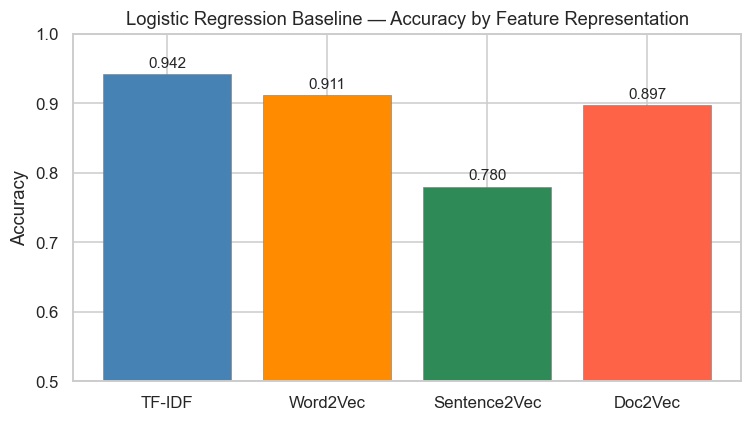

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
names = list(results.keys())
accs  = list(results.values())
bars = ax.bar(names, accs, color=['steelblue', 'darkorange', 'seagreen', 'tomato'],
              edgecolor='grey', linewidth=0.4)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('Logistic Regression Baseline — Accuracy by Feature Representation')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout(); plt.show()


## 7. Summary

| Representation | Approach | Saved file |
|---|---|---|
| TF-IDF | Sparse bag-of-words weighted by corpus rarity | `data/tfidf_dataset.csv` |
| Word2Vec | Mean-pooled skip-gram embeddings | `data/word2vec_dataset.csv` |
| Sentence2Vec | TF-IDF-weighted Word2Vec pooling | `data/sentence2vec_dataset.csv` |
| Doc2Vec | Document-level PV-DM embedding | `data/doc2vec_dataset.csv` |

See **Notebook 3** for BERT fine-tuning, which should meaningfully outperform all of the above baselines.